# EDA Process & Feature Engineering
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

In [2]:
!pip install seaborn
import pandas as pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
sales = pandas.read_csv("eabl parsed csv/eabl_sales_consolidated.csv")
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


# Sales Data Eda
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

In [1034]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1153288 entries, 0 to 1153287
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   source_file      1153288 non-null  str    
 1   salesperson      1153288 non-null  str    
 2   customer_code    1153288 non-null  str    
 3   cust_type        1153288 non-null  str    
 4   segment          1153286 non-null  str    
 5   visit_date       993617 non-null   str    
 6   product          1153288 non-null  str    
 7   quantity         1153288 non-null  float64
 8   return_quantity  1153288 non-null  int64  
dtypes: float64(1), int64(1), str(7)
memory usage: 79.2 MB


In [1035]:
sales.describe()

,quantity,return_quantity
count,1.153288e+06,1.153288e+06
mean,2.693060e+01,1.594696e+00
std,4.445434e+02,1.570681e+01
min,-9.761000e+01,0.000000e+00
25%,1.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00
75%,1.000000e+01,0.000000e+00
max,4.000000e+05,9.940000e+02


In [1036]:
print(sales.shape)

(1153288, 9)


<Axes: >

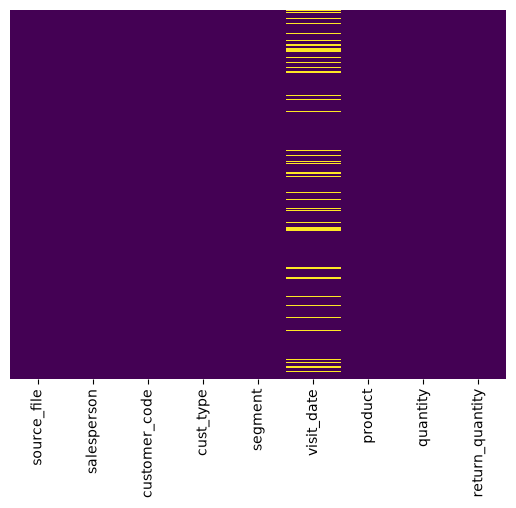

In [1037]:
sns.heatmap(sales.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [1038]:
sales.isnull().sum()

source_file             0
salesperson             0
customer_code           0
cust_type               0
segment                 2
visit_date         159671
product                 0
quantity                0
return_quantity         0
dtype: int64

In [1039]:
sales["visit_date"] = pandas.to_datetime(sales["visit_date"], format="%Y-%m-%d", errors="coerce")

In [1040]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

In [1041]:
sales["visit_date"].isnull().sum()

np.int64(159671)

In [1042]:
sales["visit_date"].dtype

dtype('<M8[us]')

In [1043]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

# Check for unique values in the customer_code column

In [1044]:
sales["customer_code"].value_counts().head(1000000)

customer_code
Total                42680
Sales Quantity       42669
Van closing Stock    37829
Van opening Stock    34892
KE0159054            14647
                     ...  
KE0142046                2
KE0062268                1
KE0062000                1
KE0062278                1
KE0171004                1
Name: count, Length: 954, dtype: int64

# Van Opening Stock Inspection


In [1045]:
sales.loc[sales["customer_code"].isin(["Van opening Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2611,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,583.00,0
2612,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,49.88,0
2613,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,17.25,0
2614,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,604.00,0
2615,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,29.00,0
...,...,...,...,...,...,...,...,...,...
1153245,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153246,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,2.00,0
1153247,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,J Wlkr Black 75Cl 12Y 12X01,3.00,0
1153248,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Captain Morgan Long Island Cocktail 75cl 10Y 1...,2.00,0


In [1046]:
sales.loc[
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2611,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,583.00,0
2612,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,49.88,0
2613,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,17.25,0
2614,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,604.00,0
2615,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,29.00,0
...,...,...,...,...,...,...,...,...,...
1153245,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153246,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,2.00,0
1153247,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,J Wlkr Black 75Cl 12Y 12X01,3.00,0
1153248,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Captain Morgan Long Island Cocktail 75cl 10Y 1...,2.00,0


#### Find the Sum of the unique value Van Opening Stock whose dates are NaT

In [1047]:
(
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(34892)

# Van Closing Stock Inspection

In [1048]:
sales.loc[sales["customer_code"].isin(["Van closing Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2823,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,516.00,0
2824,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,33.52,0
2825,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,10.75,0
2826,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,493.00,0
2827,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,23.00,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


In [1049]:
sales.loc[
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2823,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,516.00,0
2824,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,33.52,0
2825,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,10.75,0
2826,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,493.00,0
2827,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,23.00,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


### Find the Sum of the unique value Van Closing Stock whose dates are NaT

In [1050]:
(
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(37829)

## Sales Quantity Unique Value Inspection to Find the sum of visit_date which are NaT

In [1051]:
(
    (sales["customer_code"].isin(["Sales Quantity"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(42669)

In [1052]:
(
    (sales["customer_code"].isin(["Total"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(42680)

# Removing of NaT visit_date value rows since they are equally liked to the following:
### Total                46666
### Sales Quantity       42669
### Van closing Stock    41785
### Van opening Stock    34892
## Which are not actual customer codes

In [1053]:
sales = sales.dropna(subset=["visit_date"])

In [1054]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            2
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

In [1055]:
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


# Salesperson Inspection

In [1056]:
sales["salesperson"].value_counts().head(1000000)

salesperson
ELISHA MARWA-TOWN B              109644
JOSPHAT ONDIGO-PIPELINE           95805
TONY MULEI-LANET                  93140
JOHN MWANGI-CBD                   91564
VINCENT MUSERA-OLK ROUTE          91258
KEY ACCOUNT                       86609
ERASTUS LIMO-BAHATIHESHIMA        83771
JOEL MAINA MWAURA-UDV VAN         73772
JOSEPH MWANIKI-KANU               72516
SEBASTIAN MUKHANZI-GILGIL         68340
ERIC KIAMA -OLK COUNTER           61552
WELDON KIRUI - NDUNDORI ROUTE     56837
Marvin Odhiambo                    3550
Vivian Jebiwott Yatich             2917
Martha  Mwende                     1190
Clare Wanyaga                       449
Barbara Mwatu                       302
Dennis Mutai                        138
Patrick Mukuna                      110
Evans Odero                          74
Norween  Kimalit                     41
Patricia Kinuthia                    26
Valentine Irungu                     12
Name: count, dtype: int64

# cust_type Inspection

In [1057]:
sales["cust_type"].value_counts().head(1000000)

cust_type
Cash      902227
Credit     91390
Name: count, dtype: int64

# Segment Inspection

In [1058]:
sales["segment"].value_counts().head(1000000)

segment
Bar                 483786
Specialist Store    401325
Wholesaler           35281
Event                20115
Lodging              14638
Nightclub            13448
Restaurant            7298
Marketplace           6579
Supermarket           5353
Recreation            3624
Convenience           2132
Not Applicable          36
Name: count, dtype: int64

In [1059]:
sales["product"].value_counts().head(1000000)

product
Euroform Amber Local 500ml               57490
Smirldb&Guarana 330ml Can 24X01          42613
Kenya Cane Lemon & Ginger 25cl 40X01     35657
Smirnf Ice PP R 330ml CAN 24X01 local    34298
Kenya Cane Pneap 25cl 40X01              32161
                                         ...  
Complete - Mop up empties                    1
Manyatta Sweet Cider 300ml 06X04 BBIC        1
Ciroc Red Berry 70cl      06X01              1
Singleton of Dufftown 70cl 21Y 04X01         1
JW GOT SngOfIce 1L 12X01 GOT                 1
Name: count, Length: 259, dtype: int64

In [1060]:
sales["quantity"].value_counts().head(1000000)

quantity
1.00     213680
2.00     111622
3.00      64897
5.00      64610
0.04      62645
          ...  
4.54          1
28.13         1
34.38         1
27.92         1
16.29         1
Name: count, Length: 1312, dtype: int64

# Will need normalization later

In [1061]:
sales["quantity"].describe()

count    993617.000000
mean         13.366132
std         471.931426
min         -48.000000
25%           0.600000
50%           2.000000
75%           5.000000
max      400000.000000
Name: quantity, dtype: float64

In [1062]:
print("skew:", sales["quantity"].skew())
print("rows where quantity <= 0:", (sales["quantity"] <= 0).sum())
print("99th percentile:", sales["quantity"].quantile(0.99))

skew: 650.0444634088283
rows where quantity <= 0: 99
99th percentile: 200.0


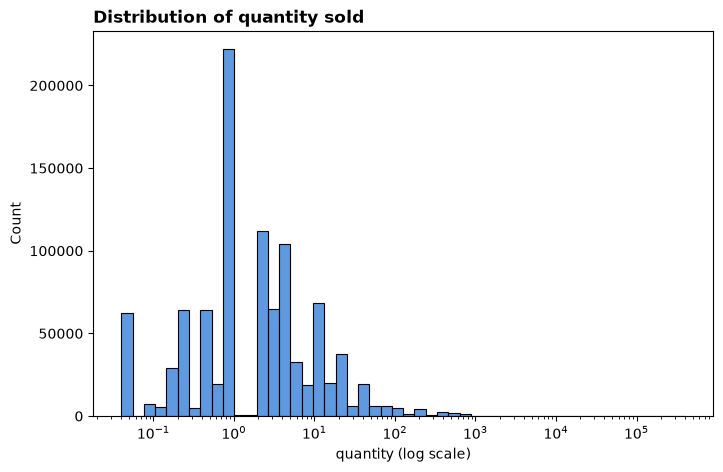

In [1063]:
positive_qty = sales.loc[sales["quantity"] > 0, "quantity"]

plt.figure(figsize=(8, 5))
sns.histplot(positive_qty, bins=50, log_scale=True, color="#2a78d6")
plt.xlabel("quantity (log scale)")
plt.title("Distribution of quantity sold", loc="left", fontsize=12, fontweight="bold")
plt.show()

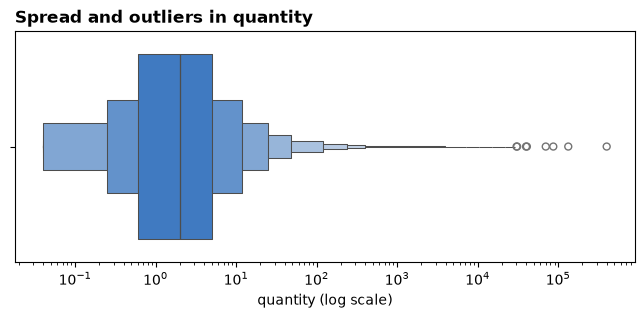

In [1064]:
plt.figure(figsize=(8, 3))
sns.boxenplot(x=positive_qty, color="#2a78d6")
plt.xscale("log")
plt.xlabel("quantity (log scale)")
plt.title("Spread and outliers in quantity", loc="left", fontsize=12, fontweight="bold")
plt.show()

In [1065]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            2
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

In [1066]:
sales["segment"] = sales["segment"].fillna("Bar")

In [1118]:
sales[sales["segment"].isnull()]
merged_sales_customers

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [1068]:
segment_pct = sales["segment"].value_counts(normalize=True) * 100
segment_pct


segment
Bar                 48.689586
Specialist Store    40.390311
Wholesaler           3.550765
Event                2.024422
Lodging              1.473203
Nightclub            1.353439
Restaurant           0.734488
Marketplace          0.662126
Supermarket          0.538739
Recreation           0.364728
Convenience          0.214570
Not Applicable       0.003623
Name: proportion, dtype: float64

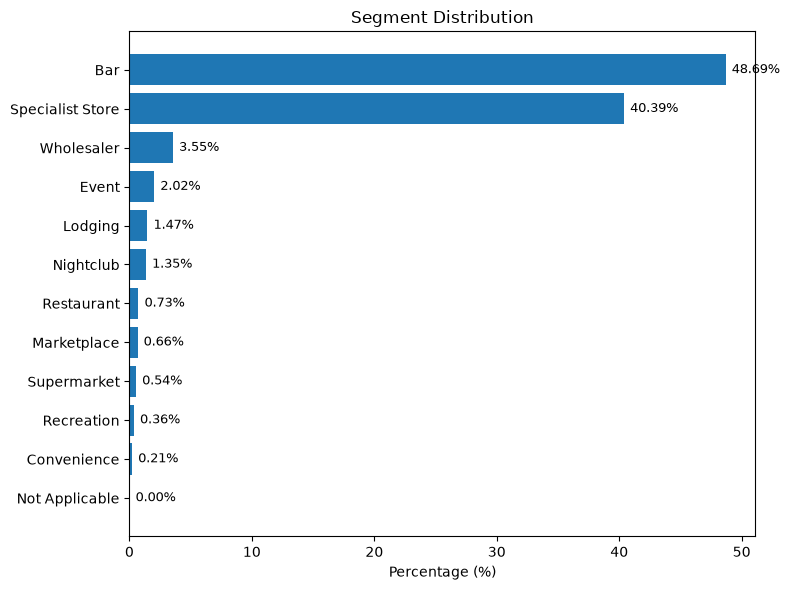

In [1069]:

segment_pct_sorted = segment_pct.sort_values()  # ascending, since barh draws bottom-up

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(segment_pct_sorted.index, segment_pct_sorted.values)

ax.set_xlabel("Percentage (%)")
ax.set_title("Segment Distribution")

# label each bar with its percentage
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{width:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Bars and Specialist stores make up the majority of the Segment distribution

In [1070]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

# Customer Dataset Eda
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

### 1. Explore Missing Values

In [ ]:
print(f"sales rows:  {len(sales)}")
print(f"merged rows: {len(merged_sales_customers)}")

In [ ]:
unmatched_mask = merged_sales_customers["DMS Customer Code"].isna()
print(f"Unmatched rows: {unmatched_mask.sum()} ({unmatched_mask.mean():.2%})")

In [ ]:
sales_norm = sales["customer_code"].str.strip().str.upper()
customers_norm = customers["DMS Customer Code"].str.strip().str.upper()

normalized_match_rate = sales_norm.isin(customers_norm).mean()
print(f"Original match rate:   {(~unmatched_mask).mean():.2%}")
print(f"Normalized match rate: {normalized_match_rate:.2%}")

In [ ]:
total_customers_in_sales = sales["customer_code"].nunique()
unmatched_customer_count = unmatched_customers.nunique()
print(f"{unmatched_customer_count} of {total_customers_in_sales} distinct customers ({unmatched_customer_count/total_customers_in_sales:.2%}) never matched")

In [ ]:
NON_CUSTOMER_LABELS = {"Total", "Sales Quantity", "Van closing Stock", "Van opening Stock", "TARGET", "VAR %"}

fake_rows = sales[sales["customer_code"].isin(NON_CUSTOMER_LABELS)]
fake_rows.head(100)

In [ ]:
merged_sales_customers_clean

In [ ]:
NON_CUSTOMER_LABELS = {"Total", "Sales Quantity", "Van closing Stock", "Van opening Stock", "TARGET", "VAR %"}
merged_clean = merged_sales_customers_clean.loc[~merged_sales_customers_clean["customer_code"].isin(NON_CUSTOMER_LABELS)].copy()
merged_clean = merged_clean.loc[merged_clean["DMS Customer Code"].notna()].copy()

print(f"Before: {len(merged_sales_customers_clean)}, after: {len(merged_clean)}")
print(f"Any fake labels left? {merged_clean['customer_code'].isin(NON_CUSTOMER_LABELS).any()}")
print(f"Any unmatched rows left? {merged_clean['DMS Customer Code'].isna().any()}")

In [ ]:
merged_clean.head(1000)

In [ ]:
merged_clean.isna().sum()

In [ ]:
merged_clean["Cookies Policy"].unique()

In [ ]:
merged_clean["Privacy Policy"].unique()

In [ ]:
merged_clean["Address"].unique()

In [ ]:
merged_clean["RSS First Login Date"].unique()

In [ ]:
COLUMNS_TO_REMOVE = [
    "Distributor Code",
    "Price Group",
    "Segment",
    "Route",
    "Address",
    "Contact Detail",
    "Approval Status",
    "Cutsomer Type",
    "GPS Co-ordinate",
    "Terms and Conditions Policy",
    "Privacy Policy",
    "Cookies Policy",
]

print(f"Removing {len(COLUMNS_TO_REMOVE)} columns")
merged_clean = merged_clean.drop(columns=COLUMNS_TO_REMOVE)
print(f"Remaining columns ({len(merged_clean.columns)}):", merged_clean.columns.tolist())


In [ ]:
merged_clean.isna().sum()

In [ ]:
merged_clean.isna().sum()

In [ ]:
merged_clean

In [ ]:
merged_clean["RSS Last Login Date"].unique()

In [ ]:
merged_clean[merged_clean['RSS Last Login Date'].isnull()]
merged_clean['RSS Last Login Date'].isnull().sum()

In [ ]:
merged_clean

# Products

In [ ]:
products = pandas.read_excel("EABL dataset/PRODUCT MASTER UPDATED-JULY 2026.xlsx")
products

In [ ]:
print(products.shape)


In [ ]:
products.isnull().sum()

In [ ]:
print(customers.columns.tolist())


In [ ]:
print(products.columns.tolist())

In [ ]:
print(sales["customer_code"].dtype, customers["DMS Customer Code"].dtype)
print(sales["product"].dtype, products["Product_Description"].dtype)

In [ ]:
customer_match_rate = sales["customer_code"].isin(customers["DMS Customer Code"]).mean()
product_match_rate = sales["product"].isin(products["Product_Description"]).mean()
print(f"customer_code match rate: {customer_match_rate:.4f}")
print(f"product match rate: {product_match_rate:.4f}")

In [ ]:
unmatched_customers = sales.loc[~sales["customer_code"].isin(customers["DMS Customer Code"]), "customer_code"]
unmatched_customers.value_counts().head(20)

In [ ]:
customers["Cust Status"].value_counts()
customers["Cust Status"].value_counts(normalize=True)

In [ ]:
print(sales["product"].nunique())
print(products["Product_Description"].nunique())

In [ ]:
sales["visit_date"] = pandas.to_datetime(sales["visit_date"])
print(sales["visit_date"].min(), sales["visit_date"].max())
sales.groupby(sales["visit_date"].dt.to_period("M")).size()

In [ ]:
sales.isnull().sum()
customers.isnull().sum()
products.isnull().sum()
(sales["quantity"] < 0).sum()